In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import os
from pathlib import Path

# Thư mục outputs (pipeline mới)
OUTPUTS_DIR = Path("../outputs")
FIG_DIR = OUTPUTS_DIR / "figures"
MODEL_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Đã nạp xong thư viện và cấu hình thư mục outputs/.")

✅ Đã nạp xong thư viện và cấu hình thư mục outputs/.


In [2]:
# 1) Load model (ưu tiên best_model.pkl từ outputs/)
best_model_path = MODEL_DIR / "best_model.pkl"
if best_model_path.exists():
    model_path = best_model_path
else:
    # fallback: model cũ trong artifacts (nếu có)
    model_path = Path("../artifacts/models/xgboost_best_model.pkl")

loaded_model = joblib.load(model_path)
print(f"✅ Đã tải mô hình thành công từ: {model_path}")

# 2) Load X_test, y_test (ưu tiên từ outputs/metrics)
# Tự động tìm file mới nhất theo prefix
x_candidates = sorted(METRICS_DIR.glob("X_test_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
y_candidates = sorted(METRICS_DIR.glob("y_test_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

if x_candidates and y_candidates:
    X_test = pd.read_csv(x_candidates[0])
    y_test = pd.read_csv(y_candidates[0])["is_return"]
    print(f"✅ Đã nạp X_test/y_test từ outputs: {x_candidates[0].name}, {y_candidates[0].name}")
else:
    print("⚠️ Chưa thấy X_test/y_test trong outputs/metrics. Sẽ load từ module src (nếu có).")

✅ Đã tải mô hình thành công từ: ..\outputs\models\best_model.pkl


✅ Đã nạp X_test/y_test từ outputs: X_test_20260317-155908.csv, y_test_20260317-155908.csv


In [3]:
import sys
import os

# Nếu chưa load được X_test/y_test từ outputs thì mới fallback sang src
if "X_test" not in globals() or "y_test" not in globals():
    sys.path.append(os.path.abspath('..'))
    from src.models.models import RetailReturnModeler

    modeler = RetailReturnModeler()
    X_train, X_test, y_train, y_test = modeler.load_and_split_data()

    print("✅ Đã nạp thành công X_test và y_test từ module src!")

In [4]:
# Dự đoán nhãn (0: Không trả hàng, 1: Có trả hàng)
y_pred = loaded_model.predict(X_test)

# Dự đoán xác suất (Dùng để vẽ các biểu đồ nâng cao như ROC-AUC nếu cần)
y_pred_proba = loaded_model.predict_proba(X_test)[:, 1] 

print("✅ Đã hoàn tất dự đoán trên tập Test.")

✅ Đã hoàn tất dự đoán trên tập Test.


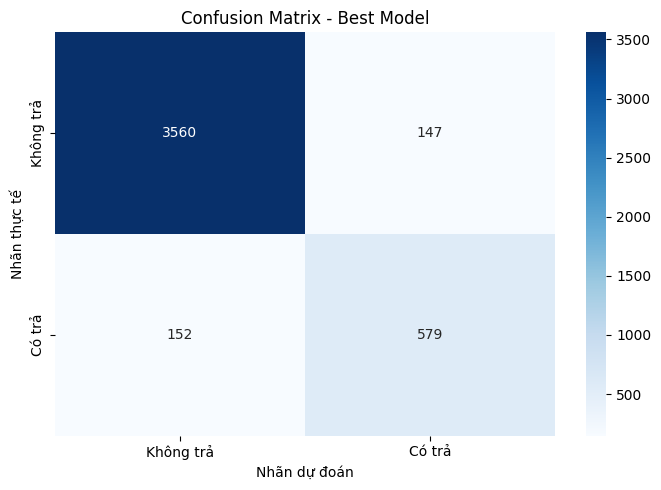

✅ Đã lưu Confusion Matrix: ..\outputs\figures\confusion_matrix_best_model.png


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Không trả', 'Có trả'],
    yticklabels=['Không trả', 'Có trả'],
)
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()

out_path = FIG_DIR / 'confusion_matrix_best_model.png'
plt.savefig(out_path, dpi=150)
plt.show()
print(f"✅ Đã lưu Confusion Matrix: {out_path}")

In [6]:
# In báo cáo đánh giá chi tiết
print("BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Không trả', 'Có trả']))

BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):
--------------------------------------------------
              precision    recall  f1-score   support

   Không trả       0.96      0.96      0.96      3707
      Có trả       0.80      0.79      0.79       731

    accuracy                           0.93      4438
   macro avg       0.88      0.88      0.88      4438
weighted avg       0.93      0.93      0.93      4438



In [7]:
# Phân tích lỗi: False Positive / False Negative theo phân khúc
import numpy as np

# Nếu X_test là numpy array thì chuyển về DataFrame
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test)
else:
    X_test_df = X_test.copy()

# Chuẩn hóa index
X_test_df = X_test_df.reset_index(drop=True)
y_test_s = pd.Series(y_test).reset_index(drop=True)
y_pred_s = pd.Series(y_pred).reset_index(drop=True)

fp_mask = (y_test_s == 0) & (y_pred_s == 1)
fn_mask = (y_test_s == 1) & (y_pred_s == 0)

print("FP count:", int(fp_mask.sum()), "FN count:", int(fn_mask.sum()))

# Tạo bins theo quantile cho vài feature numeric (nếu tồn tại)
num_cols = [c for c in X_test_df.columns if np.issubdtype(X_test_df[c].dtype, np.number)]
num_cols = num_cols[:6]  # giới hạn cho gọn

error_profiles = []
for col in num_cols:
    try:
        bins = pd.qcut(X_test_df[col], q=4, duplicates='drop')
        tmp = pd.DataFrame({
            'feature': col,
            'bin': bins.astype(str),
            'count': X_test_df.groupby(bins).size().values,
            'fp_rate': fp_mask.groupby(bins).mean().values,
            'fn_rate': fn_mask.groupby(bins).mean().values,
        })
        error_profiles.append(tmp)
    except Exception:
        continue

if error_profiles:
    prof_df = pd.concat(error_profiles, ignore_index=True)
    display(prof_df.sort_values(['feature','bin']))
else:
    print("Không đủ feature numeric để phân tích theo bins.")

# Nếu có Country (hoặc onehot Country_), phân tích FP/FN theo Country
country_cols = [c for c in X_test_df.columns if 'Country' in str(c)]
if 'Country' in X_test_df.columns:
    seg = X_test_df['Country'].astype(str)
    seg_df = pd.DataFrame({
        'segment': seg,
        'n': seg.value_counts(),
    })
    seg_df['fp_rate'] = fp_mask.groupby(seg).mean()
    seg_df['fn_rate'] = fn_mask.groupby(seg).mean()
    seg_df = seg_df.fillna(0).sort_values('fn_rate', ascending=False)
    print("=== FP/FN theo Country ===")
    display(seg_df.head(15))
else:
    # Nếu đã one-hot, lấy top country có FN cao bằng cách cộng group theo cột
    onehot_countries = [c for c in country_cols if str(c).startswith('Country_')]
    if onehot_countries:
        rows = []
        for c in onehot_countries:
            seg_mask = X_test_df[c] == 1
            if seg_mask.sum() < 20:
                continue
            rows.append({
                'segment': c.replace('Country_',''),
                'n': int(seg_mask.sum()),
                'fp_rate': float(fp_mask[seg_mask].mean()),
                'fn_rate': float(fn_mask[seg_mask].mean()),
            })
        if rows:
            seg_df = pd.DataFrame(rows).sort_values('fn_rate', ascending=False)
            print("=== FP/FN theo Country (one-hot) ===")
            display(seg_df.head(15))


FP count: 147 FN count: 152


Không đủ feature numeric để phân tích theo bins.
=== FP/FN theo Country (one-hot) ===


C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_10100\453772963.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'count': X_test_df.groupby(bins).size().values,
C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_10100\453772963.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'fp_rate': fp_mask.groupby(bins).mean().values,
C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_10100\453772963.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

,segment,n,fp_rate,fn_rate
4,Spain,20,0.000000,0.100000
3,Germany,116,0.051724,0.043103
6,United Kingdom,3979,0.031164,0.034933
2,France,96,0.072917,0.010417
0,Belgium,26,0.000000,0.000000
1,EIRE,63,0.047619,0.000000
5,Switzerland,20,0.050000,0.000000


## Dự báo Return Rate theo tháng (ARIMA - statsmodels)

Yêu cầu Đề tài 13: Dự báo **tỉ lệ trả hàng (return rate)** theo tháng dựa trên `InvoiceDate`.

- Ta tính return rate theo tháng ở mức **hóa đơn** (InvoiceNo): một hóa đơn được xem là trả hàng nếu có ít nhất 1 dòng `is_return=1`.
- Sau đó fit mô hình **ARIMA** và dự báo cho vài tháng tiếp theo.


✅ Đã lưu forecast ARIMA: ..\outputs\metrics\return_rate_forecast_arima.csv


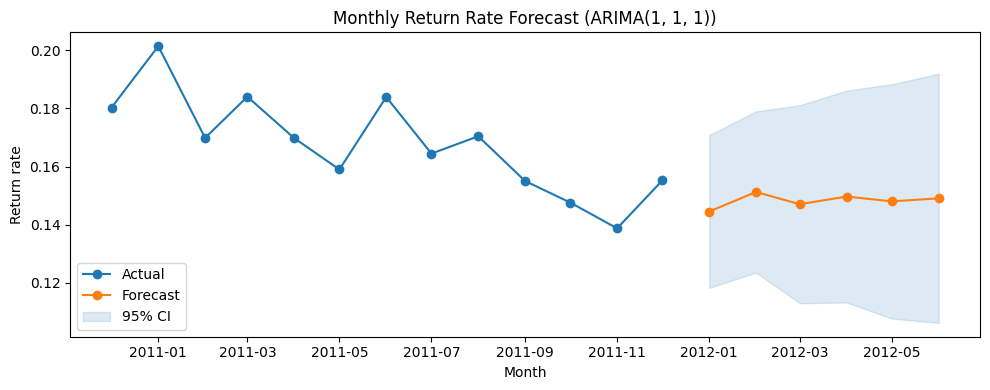

✅ Đã lưu hình dự báo: ..\outputs\figures\return_rate_forecast_arima.png


In [8]:
import yaml
from statsmodels.tsa.arima.model import ARIMA

# Load cleaned data để tính return rate theo tháng
cleaned_path = Path("../data/processed/cleaned.csv")
df_clean = pd.read_csv(
    cleaned_path,
    encoding="ISO-8859-1",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": str, "StockCode": str},
)

# Invoice-level is_return (max theo InvoiceNo)
inv = df_clean.groupby("InvoiceNo").agg(
    InvoiceDate=("InvoiceDate", "max"),
    is_return=("is_return", "max"),
).reset_index()

inv["Month"] = inv["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly = inv.groupby("Month")["is_return"].mean().rename("return_rate").to_frame()

# Reindex theo tháng liên tục
monthly = monthly.asfreq("MS")
monthly["return_rate"] = monthly["return_rate"].interpolate(limit_direction="both")

# ARIMA params từ configs
with open("../configs/params.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

order = tuple(cfg.get("time_series", {}).get("arima_order", [1, 1, 1]))
periods = int(cfg.get("time_series", {}).get("forecast_periods", 6))

model = ARIMA(monthly["return_rate"], order=order)
fit = model.fit()
forecast = fit.get_forecast(steps=periods)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

# Lưu forecast
forecast_df = pd.DataFrame({
    "month": forecast_mean.index,
    "return_rate_forecast": forecast_mean.values,
    "ci_lower": forecast_ci.iloc[:, 0].values,
    "ci_upper": forecast_ci.iloc[:, 1].values,
})

out_csv = METRICS_DIR / "return_rate_forecast_arima.csv"
forecast_df.to_csv(out_csv, index=False)
print(f"✅ Đã lưu forecast ARIMA: {out_csv}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly["return_rate"], label="Actual", marker="o")
plt.plot(forecast_mean.index, forecast_mean.values, label="Forecast", marker="o")
plt.fill_between(
    forecast_mean.index,
    forecast_df["ci_lower"],
    forecast_df["ci_upper"],
    color="tab:blue",
    alpha=0.15,
    label="95% CI",
)
plt.title(f"Monthly Return Rate Forecast (ARIMA{order})")
plt.xlabel("Month")
plt.ylabel("Return rate")
plt.legend()
plt.tight_layout()

out_fig = FIG_DIR / "return_rate_forecast_arima.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print(f"✅ Đã lưu hình dự báo: {out_fig}")


In [9]:
# Top sản phẩm rủi ro cao (return rate theo StockCode/Description) để gắn vào insight hành động
prod = df_clean.groupby(["StockCode", "Description"]).agg(
    n_lines=("is_return", "size"),
    return_rate=("is_return", "mean"),
).reset_index()

# Lọc để tránh tỷ lệ nhiễu do quá ít giao dịch
prod = prod[prod["n_lines"] >= 20].copy()
top10_prod = prod.sort_values("return_rate", ascending=False).head(10)

out_top = METRICS_DIR / "top10_risky_products.csv"
top10_prod.to_csv(out_top, index=False)
print(f"✅ Đã lưu Top 10 sản phẩm rủi ro: {out_top}")

display(top10_prod)


✅ Đã lưu Top 10 sản phẩm rủi ro: ..\outputs\metrics\top10_risky_products.csv


,StockCode,Description,n_lines,return_rate
3908,D,Discount,77,1.000000
3910,M,Manual,459,0.381264
1981,23064,CINDERELLA CHANDELIER,32,0.312500
1549,22656,VINTAGE BLUE KITCHEN CABINET,26,0.230769
1114,22198,LARGE POPCORN HOLDER,68,0.220588
2445,23462,ROCOCO WALL MIRROR WHITE,55,0.218182
1359,22461,SAVOY ART DECO CLOCK,57,0.210526
577,21424,WOODLAND STORAGE BOX LARGE,27,0.185185
3506,85159B,"WHITE TEA,COFFEE,SUGAR JARS",72,0.180556
1548,22655,VINTAGE RED KITCHEN CABINET,46,0.173913


## 5 Insight Actionable (kèm hành động cụ thể)

1) **Kiểm duyệt đơn hàng rủi ro cao (Top risk orders)**
- **Insight**: các đơn có xác suất `is_return=1` cao sẽ tạo chi phí hoàn hàng lớn nếu xử lý như đơn bình thường.
- **Action**: thiết lập rule “Review thủ công” cho **top 5–10% đơn có score cao nhất** (gọi xác nhận kỳ vọng, kiểm tra thông tin, tư vấn thêm trước khi xuất kho).

2) **Giảm False Negative bằng tuning ngưỡng quyết định (threshold tuning)**
- **Insight**: FN = dự đoán “không trả” nhưng thực tế “có trả” → doanh nghiệp bị động, tốn chi phí vận hành.
- **Action**: chọn threshold theo **PR-AUC / chi phí hoàn hàng** (không dùng mặc định 0.5). Ví dụ: hạ threshold để tăng recall lớp trả hàng, sau đó đo trade-off FP/FN trong báo cáo.

3) **Tối ưu nội dung & chất lượng cho Top sản phẩm rủi ro**
- **Insight**: một số SKU có **return rate cao** (xem bảng `top10_risky_products.csv` vừa xuất trong `outputs/metrics/`).
- **Action**: với Top 10 SKU này, thực hiện checklist 3 bước: 
  - cập nhật ảnh thực tế + mô tả rõ size/màu/chất liệu,
  - bổ sung FAQ/hướng dẫn sử dụng,
  - kiểm tra lại chất lượng/đóng gói theo SKU (đặc biệt nếu nhiều return do hư hỏng/thiếu phụ kiện).

4) **Chính sách theo phân khúc khách hàng (segment-based policy)**
- **Insight**: phân cụm (RFM + return_rate) thường cho thấy nhóm **Return-prone** và nhóm **VIP/High-value**.
- **Action**:
  - **VIP**: ưu tiên chăm sóc (giao nhanh, đổi trả linh hoạt, cross-sell/upsell).
  - **Return-prone**: tăng mức tư vấn trước mua, hạn chế khuyến mại cho SKU rủi ro, hoặc yêu cầu xác nhận bổ sung.

5) **Can thiệp vận hành đóng gói/giao hàng theo lỗi FP/FN**
- **Insight**: từ bảng phân tích lỗi FP/FN theo phân khúc, doanh nghiệp có thể thấy mô hình hay sai ở nhóm nào (ví dụ một số `Country` hoặc bin giá/số lượng).
- **Action**: 
  - nếu FN cao ở một phân khúc → tăng kiểm tra trước xuất kho cho phân khúc đó,
  - nếu FP cao → tránh làm phiền khách không rủi ro bằng cách điều chỉnh rule (threshold/segment) hoặc chỉ review thủ công trong khung giờ cao điểm.
